# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_jobs.csv")

# TF-IDF

In [3]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])

# KMeans

In [4]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

# PCA Visualization

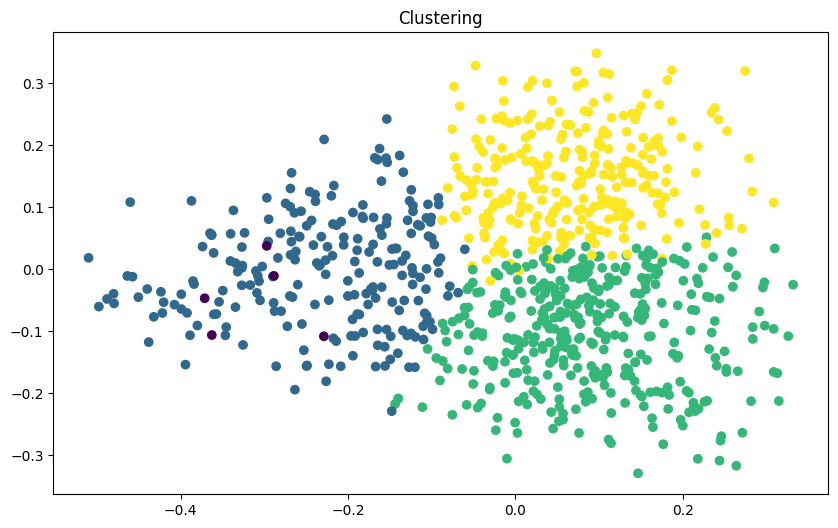

In [5]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X.toarray())

plt.figure(figsize=(10,6))
plt.scatter(reduced[:,0], reduced[:,1], c=clusters)
plt.title("Clustering")
plt.savefig('../outputs/figures/clustering.png')
plt.show()

In [6]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("../data/processed/cleaned_jobs.csv")

# Text column
texts = df['cleaned_text'].astype(str)

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=1000
)

X = vectorizer.fit_transform(texts)

# KMeans clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Fit model
df['cluster'] = kmeans.fit_predict(X)

# Save clustered dataset
df.to_csv(
    "../data/processed/clustered_jobs.csv",
    index=False
)

print("clustered_jobs.csv created successfully.")

clustered_jobs.csv created successfully.


# KMeans Clustering

In [7]:
from sklearn.cluster import KMeans

# Fit Clustering Model

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['cluster'] = kmeans.fit_predict(X)

print(df[['cleaned_text', 'cluster']].head())

                                        cleaned_text  cluster
0  junior data analyst take your next career step...        1
1  job title data scientist job description job t...        0
2  job description graduate post graduate degree ...        0
3  job description experience years data operatio...        3
4  job description you are strategic thinker pass...        1


# Save Cluster Results

In [10]:
cluster_results = df[[
    'cleaned_text',
    'cluster'
]]

cluster_results.to_csv(
    "../outputs/tables/clustering_results.csv",
    index=False
)

print("clustering_results.csv generated.")

clustering_results.csv generated.
